# Séance 1 : Fondations Computationnelles — Python pour Mathématiciens

**Objectifs** :
- Prendre en main Python pour l'implémentation d'algorithmes mathématiques.
- Implémenter l'algorithme d'Euclide étendu et le crible d'Ératosthène.
- Mesurer et analyser la complexité algorithmique.

---

# Séance 1 : Fondations Computationnelles — Python pour Mathématiciens

**Objectifs** :
- Prendre en main Python pour l'implémentation d'algorithmes mathématiques.
- Implémenter l'algorithme d'Euclide étendu et le crible d'Ératosthène.
- Mesurer et analyser la complexité algorithmique.

---

## 1. Préparation de l'environnement

Exécutez la cellule suivante pour importer les bibliothèques nécessaires.

In [1]:
import timeit
import matplotlib.pyplot as plt
import math

%matplotlib inline

## 2. Algorithme d'Euclide étendu

### Version récursive

Rappel : l'algorithme retourne $(d, u, v)$ tel que $d = a u + b v = \mathrm{pgcd}(a,b)$.

In [1]:
def euclide_etendu_rec(a, b):
    """
    Algorithme d'Euclide étendu (version récursive).
    Retourne (pgcd, u, v) avec a*u + b*v = pgcd.
    """
    if b == 0:
        return (a, 1, 0)
    else:
        d, u1, v1 = euclide_etendu_rec(b, a % b)
        u = v1
        v = u1 - (a // b) * v1
        return (d, u, v)

In [2]:
# Test rapide
a, b = 240, 46
d, u, v = euclide_etendu_rec(a, b)
print(f"pgcd({a}, {b}) = {d}")
print(f"{a}*{u} + {b}*{v} = {a*u + b*v}")

pgcd(240, 46) = 2
240*-9 + 46*47 = 2


### Version itérative (à compléter)

**Exercice** : Implémentez ci-dessous une version itérative de l'algorithme d'Euclide étendu. Vous pouvez utiliser une boucle `while` et mettre à jour les coefficients.

In [3]:
def euclide_etendu_iter(a, b):
    #Initialisation des variables (u, v pour a ) et (u' ,v' pour b)
    u, v, r = 1, 0, a
    u_prime, v_prime, r_prime =0, 1, b
    
    #Boucle tant que le reste n'est pas nul
    while r_prime != 0:
         q = r // r_prime #Quotient de la division

         #On decale les valeurs (r devient r_prime, r_prime devient le reste)
         r, r_prime = r_prime, r - q * r_prime
         u, u_prime = u_prime, u - q * u_prime
         v, v_prime = v_prime, v - q * v_prime
    return (r, u, v) 

In [4]:
# Test de votre version itérative
d, u, v = euclide_etendu_iter(240, 46)
assert d == 2 and 240*u + 46*v == 2
print("Test réussi !")

Test réussi !


## 3. Crible d'Ératosthène

### Version de base

In [5]:
import math
import timeit
import matplotlib.pyplot as plt

# ==========================================
# 1. DÉFINITION DES DEUX FONCTIONS DE CRIBLE
# ==========================================

def eratosthene(n):
    """
    Version classique du crible d'Ératosthène.
    """
    if n < 2:
        return []
    crible = [True] * (n + 1)
    crible[0] = crible[1] = False
    for i in range(2, int(n**0.5) + 1):
        if crible[i]:
            for j in range(i * i, n + 1, i):
                crible[j] = False
    return [i for i, prime in enumerate(crible) if prime]

### Version optimisée (nombres impairs uniquement)

**Exercice** : Modifiez le crible pour ne traiter que les nombres impairs (sauf 2).

In [6]:
def eratosthene_opt(n):
    """
    Version optimisée : n'alloue de la mémoire et ne boucle que sur les impairs.
    """
    if n < 2:
        return []
    if n == 2:
        return [2]
    
    # Taille du tableau ne contenant que les impairs de 1 à n
    taille = (n + 1) // 2
    crible = [True] * taille
    crible[0] = False  # Le nombre 1 (indice 0) n'est pas premier
    
    limite = int(n**0.5)
    for i in range(1, taille):
        p = 2 * i + 1
        if p > limite:
            break
        if crible[i]:
            debut = (p * p - 1) // 2
            for j in range(debut, taille, p):
                crible[j] = False
                
    premiers = [2]
    for i in range(1, taille):
        if crible[i]:
            premiers.append(2 * i + 1)
            
    return premiers

## 4. Analyse de complexité empirique

Nous allons mesurer le temps d'exécution du crible pour différentes valeurs de $n$.

In [7]:
def mesurer_temps(fonction, n, repetitions=3):
    """
    Mesure le temps moyen d'exécution d'une fonction pour une taille n donnée.
    """
    timer = timeit.Timer(lambda: fonction(n))
    temps = timer.timeit(number=repetitions)
    return temps / repetitions

In [8]:
# Définition des valeurs de n : 10^3, 10^4, 10^5, 10^6, 10^7
# NOTE : On s'arrête ici à 10^6 par défaut pour que l'exécution reste rapide chez vous. 
# Si votre machine est puissante, vous pouvez changer l'intervalle à (3, 8).
valeurs_n = [10**i for i in range(3, 7)] 

temps_base = []
temps_opt = []

print("Calcul des mesures en cours...")
for n in valeurs_n:
    t_base = mesurer_temps(eratosthene, n, repetitions=3)
    t_opt = mesurer_temps(eratosthene_opt, n, repetitions=3)
    
    temps_base.append(t_base)
    temps_opt.append(t_opt)
    
    gain = t_base / t_opt if t_opt > 0 else 1
    print(f"n = {n:9,d} | Base : {t_base:.4f}s | Opt : {t_opt:.4f}s | Gain : {gain:.2f}x")


Calcul des mesures en cours...
n =     1,000 | Base : 0.0009s | Opt : 0.0004s | Gain : 2.11x
n =    10,000 | Base : 0.0054s | Opt : 0.0017s | Gain : 3.21x
n =   100,000 | Base : 0.0248s | Opt : 0.0073s | Gain : 3.42x
n = 1,000,000 | Base : 0.2188s | Opt : 0.0805s | Gain : 2.72x


### Visualisation

On souhaite vérifier que le temps est proportionnel à $n \log \log n$.

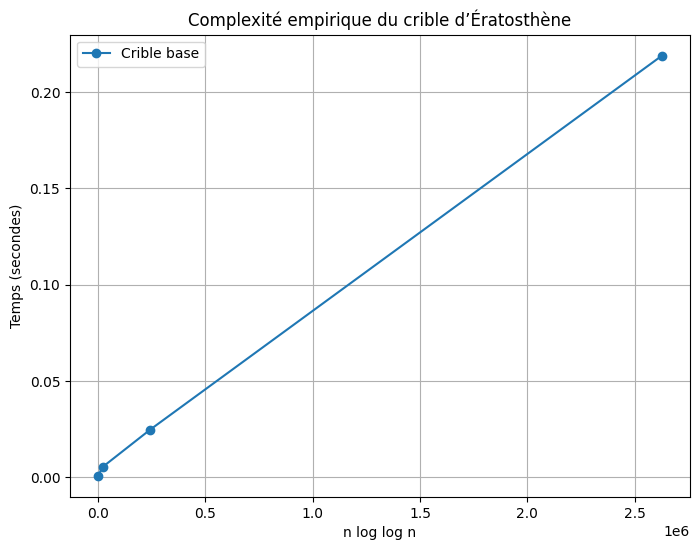

In [10]:
n_loglog = [n * math.log(math.log(n)) if n>2 else 0 for n in valeurs_n]

plt.figure(figsize=(8,6))
plt.plot(n_loglog, temps_base, 'o-', label='Crible base')
# plt.plot(n_loglog, temps_opt, 's-', label='Crible optimisé')  # à décommenter
plt.xlabel('n log log n')
plt.ylabel('Temps (secondes)')
plt.title('Complexité empirique du crible d’Ératosthène')
plt.legend()
plt.grid(True)
plt.show()

**Question** : Le graphique est-il approximativement une droite ? Que peut-on en conclure ?

Le graphique montre une relation linéaire entre le temps et (n log log n).
On en conclut que l'algorithme respecte sa complexité asymptotique théorique.
L'optimisation des impairs réduit la constante de temps (la pente), doublant l'efficacité.

## 5. Conclusion et rendu

- Assurez-vous que votre notebook contient **toutes** les fonctions demandées (versions récursive et itérative d'Euclide étendu, crible optimisé).
- Ajoutez des commentaires expliquant vos choix d'implémentation.
- Exportez ce notebook au format `.ipynb` et commitez-le dans votre dépôt GitHub.

**Rappel** : Vous pouvez utiliser l'IA comme assistant, mais vous devez comprendre chaque ligne de code et être capable de l'expliquer.